In [16]:
import matplotlib.pyplot as plt
import numpy as np

import jax
import jax.numpy as jnp
import jax.scipy.stats as stats
import jax.random as jr
import blackjax

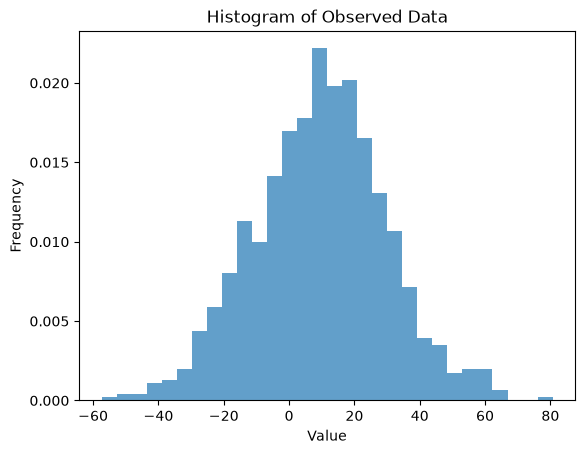

In [19]:
rng_key = jr.key(0);

loc, scale = 10, 20
observed = np.random.normal(loc, scale, size=1_000)

plt.hist(observed, bins=30, density=True, alpha=0.7)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Observed Data")
plt.show()

In [20]:
def logdensity_fn(loc, log_scale, observed=observed):
    """Univariate Normal"""
    scale = jnp.exp(log_scale)
    logjac = log_scale
    logpdf = stats.norm.logpdf(observed, loc, scale)
    return logjac + jnp.sum(logpdf)


logdensity = lambda x: logdensity_fn(**x)

In [21]:
inv_mass_matrix = np.array([0.5, 0.01])
num_integration_steps = 60
step_size = 1e-3

hmc = blackjax.hmc(logdensity, step_size, inv_mass_matrix, num_integration_steps)

initial_position = {"loc": 1.0, "log_scale": 1.0}
initial_state = hmc.init(initial_position)
initial_state

HMCState(position={'loc': 1.0, 'log_scale': 1.0}, logdensity=Array(-34552.426, dtype=float32), logdensity_grad={'loc': Array(1160.7025, dtype=float32, weak_type=True), 'log_scale': Array(64269.973, dtype=float32, weak_type=True)})

In [22]:
hmc_kernel = jax.jit(hmc.step)

def inference_loop(rng_key, kernel, initial_state, num_samples):
    @jax.jit
    def one_step(state, rng_key):
        state, _ = kernel(rng_key, state)
        return state, state

    keys = jax.random.split(rng_key, num_samples)
    _, states = jax.lax.scan(one_step, initial_state, keys)

    return states



rng_key, sample_key = jax.random.split(rng_key)
states = inference_loop(sample_key, hmc_kernel, initial_state, 10_000)

mcmc_samples = states.position
mcmc_samples["scale"] = jnp.exp(mcmc_samples["log_scale"]).block_until_ready()


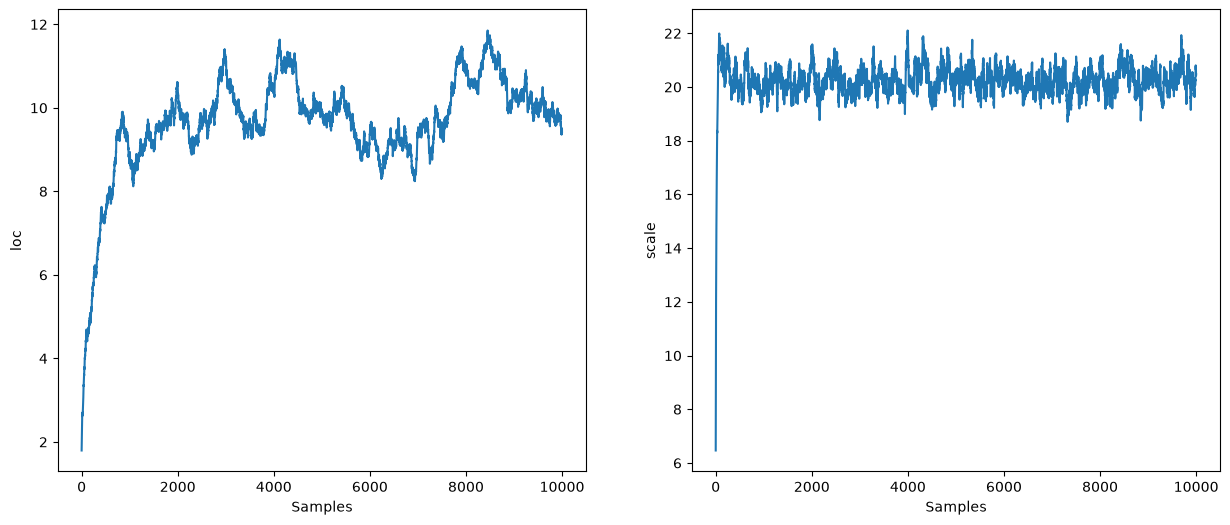

In [23]:
fig, (ax, ax1) = plt.subplots(ncols=2, figsize=(15, 6))
ax.plot(mcmc_samples["loc"])
ax.set_xlabel("Samples")
ax.set_ylabel("loc")

ax1.plot(mcmc_samples["scale"])
ax1.set_xlabel("Samples")
ax1.set_ylabel("scale");